pip install torch torchvision nltk matplotlib pandas numpy scikit-learn gensim seaborn transformers datasets sentencepiece accelerate ipykernel

In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.manifold import TSNE

import gensim.downloader as api

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import seaborn as sns
from datasets import load_dataset

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


/home/arman/it/AI_work/text/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/arman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/arman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("GPU недоступна, обучение на CPU")
print("CUDA:", torch.cuda.is_available())


NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA: True


# часть 1

In [4]:
dataset = load_dataset("imdb")

# официальный test IMDB сохраняем отдельно (не используем в этой работе)
# по заданию: 80% обучение, 20% тест — делим train IMDB
raw_train = dataset["train"]
raw_test_official = dataset["test"]

print("Train IMDB:", len(raw_train))
print("Пример:", raw_train[0])


Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /home/arman/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Thu May 28 01:25:39 2026).


Train IMDB: 25000
Пример: {'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity

In [5]:
stop_words = set(stopwords.words('english'))


def preprocess_text(text):
    text = text.lower()

    # удаление пунктуации
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = text.split()

    # удаление стоп-слов
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [6]:
for i in range(3):
    original = raw_train[i]['text']
    processed = preprocess_text(original)

    print('=' * 80)
    print('ОРИГИНАЛ:')
    print(original[:500])

    print('\nПОСЛЕ ОБРАБОТКИ:')
    print(processed[:500])

ОРИГИНАЛ:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

ПОСЛЕ ОБРАБОТКИ:
rented curious yellow video store controversy surrounded first released also heard first seized u customs ever tried enter country therefore fan films considered controversial really see br br plot centered around young swedish drama student named lena wants learn everything life particular wants focus attentions making sort documentary average swede thought certain political issues vietnam war race issues united states asking politicians ordinary denizens stockholm 

In [7]:
texts_all = [preprocess_text(t) for t in raw_train["text"]]
labels_all = list(raw_train["label"])

X_train, X_test, y_train, y_test = train_test_split(
    texts_all,
    labels_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_all,
)

print(f"Train: {len(X_train)} ({len(X_train)/len(texts_all):.0%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(texts_all):.0%})")


Train: 20000 (80%)
Test:  5000 (20%)


### Разбиение данных

По заданию: **80% train / 20% test**. Делим официальный train IMDB (25 000 отзывов) → **20 000 / 5 000** (`stratify` по меткам).

Официальный test IMDB (ещё 25 000) здесь не используем — все методы сравниваются на **одной** тестовой выборке.


### TF-IDF своими словами

**TF (term frequency)** — насколько часто слово встречается в *данном документе*. Чем чаще слово в тексте, тем выше его TF.

**IDF (inverse document frequency)** — насколько слово *редкое во всей коллекции*. Если слово есть почти в каждом документе (например, артефакты вроде `br` после очистки HTML), IDF низкий; если слово специфично для немногих отзывов — IDF высокий.

**TF-IDF = TF × IDF** — высокий вес у слов, которые **важны для конкретного документа**, но **не являются шумом для всей коллекции**. Так мы получаем компактное представление текста для классификатора без ручного подбора признаков.

**Зачем перемножать:** TF сам по себе завышает частые «пустые» слова; IDF штрафует слишком общие. Вместе получается вектор, где сильные компоненты — тематически значимые слова (для негатива: `bad`, `worst`; для позитива: `great`, `love`).


In [8]:
vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(20000, 10000)


In [9]:
feature_names = np.array(vectorizer.get_feature_names_out())

for class_id in [0, 1]:
    class_vectors = X_train_tfidf[np.array(y_train) == class_id]

    mean_tfidf = np.asarray(class_vectors.mean(axis=0)).flatten()

    top_indices = mean_tfidf.argsort()[-20:][::-1]

    print(f'\nКласс {class_id}')

    for idx in top_indices:
        print(feature_names[idx], round(mean_tfidf[idx], 4))


Класс 0
br 0.1058
movie 0.0588
film 0.0428
one 0.029
bad 0.029
like 0.0276
even 0.0227
good 0.0219
would 0.0212
really 0.02
time 0.0186
see 0.0171
acting 0.0169
plot 0.0165
could 0.0165
story 0.0165
movies 0.0164
people 0.0162
much 0.0162
get 0.0161

Класс 1
br 0.0915
movie 0.0451
film 0.044
one 0.0285
great 0.0228
good 0.0222
like 0.0218
story 0.0201
well 0.0193
see 0.0185
time 0.018
really 0.0172
love 0.0166
best 0.0163
also 0.0163
would 0.0151
people 0.0146
show 0.0143
life 0.0143
first 0.0142


In [10]:
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train_tfidf, y_train)

predictions = clf.predict(X_test_tfidf)

In [11]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)

Accuracy: 0.8896
Precision: 0.8766434648105181
Recall: 0.9068
F1: 0.8914667715296893


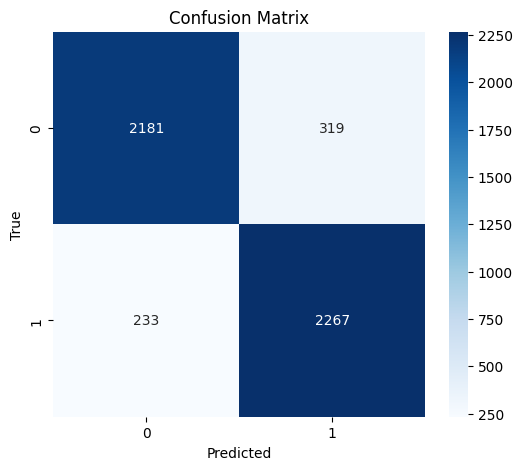

In [12]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

In [13]:
errors = []

for text, true_label, pred_label in zip(X_test, y_test, predictions):
    if true_label != pred_label:
        errors.append((text, true_label, pred_label))

print("Количество ошибок:", len(errors))


Количество ошибок: 552


In [14]:
for i in range(min(5, len(errors))):
    text, true_label, pred_label = errors[i]

    print("=" * 80)
    print("Истинная метка:", true_label, "(0=neg, 1=pos)")
    print("Предсказание:", pred_label)
    print("\nТекст (после предобработки):")
    print(text[:800])


Истинная метка: 1 (0=neg, 1=pos)
Предсказание: 0

Текст (после предобработки):
yowsa really want action check babes bombs non stop thriller veteran star martin sheen leads trio supermodels mission stop nuclear terrorism director dean hamilton let heavy plotline get way massive doses teensy swimsuit scenes jiggly beach jogs hubba hubba hot tubs like want action get pearl harbor want babes get eyeful every two minutes want go buy video yowsa yowsa yowsa mighty spicy meatballs
Истинная метка: 1 (0=neg, 1=pos)
Предсказание: 0

Текст (после предобработки):
movie shows federal pigs persons government power mad threats real life lot recommend br br alas script supervision editing even times directing flawed people disparage whole movie ignore good moments br br saw original way back new hated despised loathed thought terrible irrational piece junk br br though remember br br believe two compared even connected br br consider two different movies br br rate two different movies br br vanishing

### Анализ ошибок (3–5 примеров)

Типичные причины ошибок TF-IDF + логистической регрессии на IMDB:

1. **Смешанная тональность** — в тексте есть и похвалу, и критику; модель смотрит на отдельные слова и может «перевесить» одну сторону.
2. **Сарказм и ирония** — «great waste of time» содержит `great`, но смысл отрицательный; bag-of-words не видит порядок слов.
3. **Нейтральный тон с редкими эмоциональными словами** — описание сюжета без явных `good`/`bad`, метки при этом есть.
4. **Оговорки** — «not bad», «not the worst»; без bigram признаков «not» не отменяет следующее слово.
5. **Жанровая лексика** — слова про насилие/эротику могут коррелировать с классом, но в конкретном отзыве автор доволен фильмом.

**Вывод:** линейная модель на TF-IDF хорошо ловит «прямую» лексику тональности, но слаба на контексте, отрицании и сложной риторике.


# часть 2

In [15]:
model = api.load('glove-wiki-gigaword-100')

In [16]:
words = ['king', 'computer', 'music', 'doctor', 'school']

for word in words:
    print('=' * 60)
    print('Слово:', word)

    neighbors = model.most_similar(word, topn=5)

    for neighbor, score in neighbors:
        print(neighbor, round(score, 4))

Слово: king
prince 0.7682
queen 0.7508
son 0.7021
brother 0.6986
monarch 0.6978
Слово: computer
computers 0.8752
software 0.8373
technology 0.7642
pc 0.7366
hardware 0.729
Слово: music
musical 0.8128
songs 0.7978
dance 0.7897
pop 0.7863
recording 0.7651
Слово: doctor
physician 0.7673
nurse 0.7522
dr. 0.7175
doctors 0.7081
patient 0.7074
Слово: school
college 0.8848
schools 0.8358
elementary 0.8156
students 0.803
student 0.7812


In [17]:
result = model.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=5
)

print(result)

[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


### Векторная арифметика: `king - man + woman ≈ queen`

В GloVe каждое слово — вектор в пространстве, где близость отражает **совместную встречаемость в корпусе**. Разность векторов приближённо кодирует направление «смены признака»:

- `king - man` ≈ направление «королевская роль минус мужской пол» → что-то вроде «монархия/власть без gender=male»
- добавление `woman` переносит этот сдвиг к женскому аналогу → **`queen`**

Это не точная алгебра, а эвристика: модель выучила, что пары `(man, woman)`, `(king, queen)`, `(brother, sister)` похожи по **сдвигу в пространстве**. `most_similar(positive=[...], negative=[...])` ищет слово, ближайшее к результирующему вектору.


In [18]:
word_groups = {
    'animals': ['cat', 'dog', 'lion', 'tiger', 'wolf', 'fox', 'rabbit', 'horse'],
    'countries': ['france', 'germany', 'italy', 'china', 'japan', 'india', 'canada', 'brazil'],
    'professions': ['doctor', 'teacher', 'engineer', 'lawyer', 'nurse', 'scientist', 'pilot', 'chef'],
    'emotions': ['happy', 'sad', 'angry', 'fear', 'joy', 'love', 'hate', 'surprise']
}

vectors = []
labels = []
words_all = []

for group, words in word_groups.items():
    for word in words:
        if word in model:
            vectors.append(model[word])
            labels.append(group)
            words_all.append(word)

vectors = np.array(vectors)

In [19]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)

vectors_2d = tsne.fit_transform(vectors)

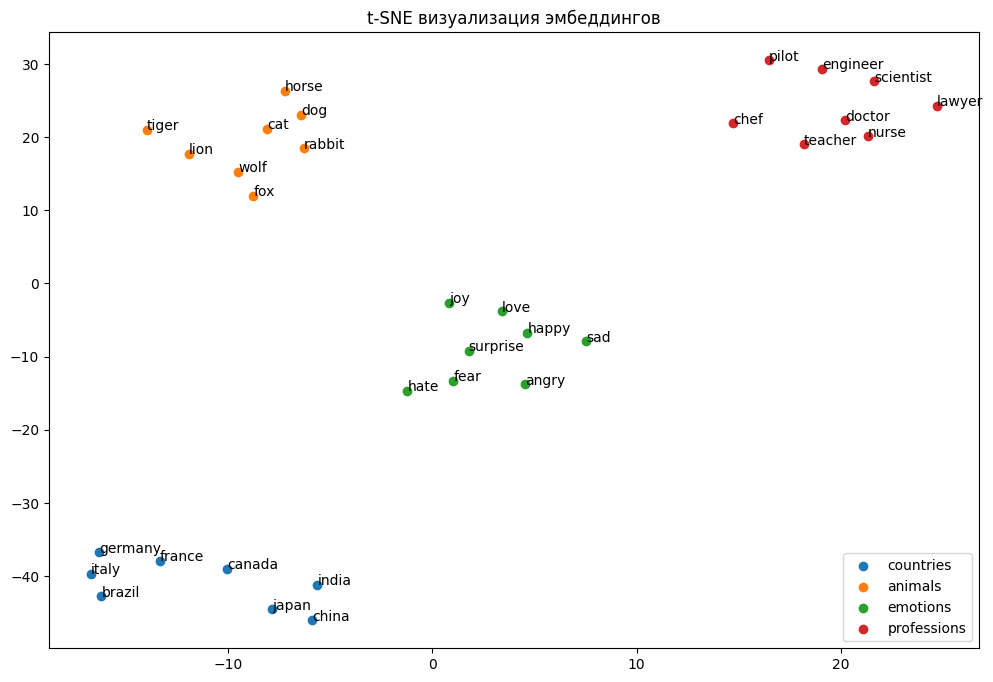

In [20]:
plt.figure(figsize=(12, 8))

for group in set(labels):
    indices = [i for i, label in enumerate(labels) if label == group]

    plt.scatter(
        vectors_2d[indices, 0],
        vectors_2d[indices, 1],
        label=group
    )

for i, word in enumerate(words_all):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.legend()
plt.title('t-SNE визуализация эмбеддингов')
plt.show()

### t-SNE: образуют ли слова кластеры?

На графике видны **частичные кластеры по темам**:

- **animals** и **countries** часто группируются отдельно — разные семантические поля.
- **professions** и **emotions** тоже тяготеют к своим областям, хотя при 32 точках и `perplexity=5` картина шумная.

Полного разделения четырёх групп нет: слова вроде `love`/`hate` близки к эмоциям, но t-SNE на малой выборке искажает глобальные расстояния. **Вывод:** статические эмбеддинги отражают семантику — соседние группы различимы, но границы размыты; для надёжной картины нужно больше слов и подбор `perplexity`.


In [21]:
EMBEDDING_SIZE = 100


def average_embedding(text):
    words = text.split()

    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(EMBEDDING_SIZE)

    return np.mean(vectors, axis=0)

In [22]:
X_train_avg = np.array([average_embedding(text) for text in X_train])
X_test_avg = np.array([average_embedding(text) for text in X_test])

In [23]:
clf_emb = LogisticRegression(max_iter=1000)

clf_emb.fit(X_train_avg, y_train)

pred_emb = clf_emb.predict(X_test_avg)

In [24]:
acc_emb = accuracy_score(y_test, pred_emb)

print('Accuracy (average embeddings):', acc_emb)

Accuracy (average embeddings): 0.7928


# часть 3

In [25]:
MAX_VOCAB = 20000
MAX_LEN = 200
EMBEDDING_DIM = 100

In [26]:
word_counter = Counter()

for text in X_train:
    word_counter.update(text.split())

most_common = word_counter.most_common(MAX_VOCAB - 2)

In [27]:
word2idx = {
    '<PAD>': 0,
    '<UNK>': 1
}

for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

In [28]:
def encode_text(text):
    tokens = text.split()

    encoded = []

    for token in tokens[:MAX_LEN]:
        encoded.append(word2idx.get(token, 1))

    while len(encoded) < MAX_LEN:
        encoded.append(0)

    return encoded

In [29]:
# разбиение train на train/val для графиков (80/20 внутри train)
X_tr_text, X_val_text, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

X_tr_encoded = np.array([encode_text(t) for t in X_tr_text])
X_val_encoded = np.array([encode_text(t) for t in X_val_text])
X_test_encoded = np.array([encode_text(t) for t in X_test])


In [30]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [31]:
train_dataset = TextDataset(X_tr_encoded, y_tr)
val_dataset = TextDataset(X_val_encoded, y_val)
test_dataset = TextDataset(X_test_encoded, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)


In [32]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_matrix=None, freeze=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM)

        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            self.embedding.weight.requires_grad = not freeze

        self.fc1 = nn.Linear(EMBEDDING_DIM, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.embedding(x)

        # GlobalAveragePooling
        x = x.mean(dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [33]:
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(len(word2idx), EMBEDDING_DIM)
)

for word, idx in word2idx.items():
    if word in model:
        embedding_matrix[idx] = model[word]

In [34]:
def _run_epoch(model_nn, loader, criterion=None, optimizer=None):
    """Одна эпоха: train (если optimizer) или eval."""
    is_train = optimizer is not None
    model_nn.train(is_train)
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        if is_train:
            optimizer.zero_grad()
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / total, correct / total


def train_model(model_nn, train_loader, val_loader, test_loader, epochs=12, label="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }

    for epoch in range(epochs):
        tr_loss, tr_acc = _run_epoch(model_nn, train_loader, criterion, optimizer)
        va_loss, va_acc = _run_epoch(model_nn, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"[{label}] epoch {epoch+1}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}")

    _, test_acc = _run_epoch(model_nn, test_loader, criterion)
    history["test_acc"] = test_acc
    print(f"[{label}] test accuracy = {test_acc:.4f}")
    return history


def plot_training_history(hist, title):
    epochs = range(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist["train_loss"], label="train")
    axes[0].plot(epochs, hist["val_loss"], label="val")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, hist["train_acc"], label="train")
    axes[1].plot(epochs, hist["val_acc"], label="val")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


[Random Embedding] epoch 1/12  train_loss=0.6573  train_acc=0.6058  val_loss=0.5447  val_acc=0.7612
[Random Embedding] epoch 2/12  train_loss=0.4147  train_acc=0.8186  val_loss=0.3871  val_acc=0.8313
[Random Embedding] epoch 3/12  train_loss=0.3033  train_acc=0.8716  val_loss=0.3387  val_acc=0.8610
[Random Embedding] epoch 4/12  train_loss=0.2343  train_acc=0.9068  val_loss=0.3207  val_acc=0.8692
[Random Embedding] epoch 5/12  train_loss=0.1854  train_acc=0.9308  val_loss=0.3185  val_acc=0.8728
[Random Embedding] epoch 6/12  train_loss=0.1588  train_acc=0.9404  val_loss=0.3295  val_acc=0.8782
[Random Embedding] epoch 7/12  train_loss=0.1292  train_acc=0.9546  val_loss=0.3611  val_acc=0.8730
[Random Embedding] epoch 8/12  train_loss=0.1007  train_acc=0.9683  val_loss=0.3576  val_acc=0.8785
[Random Embedding] epoch 9/12  train_loss=0.0838  train_acc=0.9739  val_loss=0.3782  val_acc=0.8780
[Random Embedding] epoch 10/12  train_loss=0.0708  train_acc=0.9787  val_loss=0.4059  val_acc=0.8738

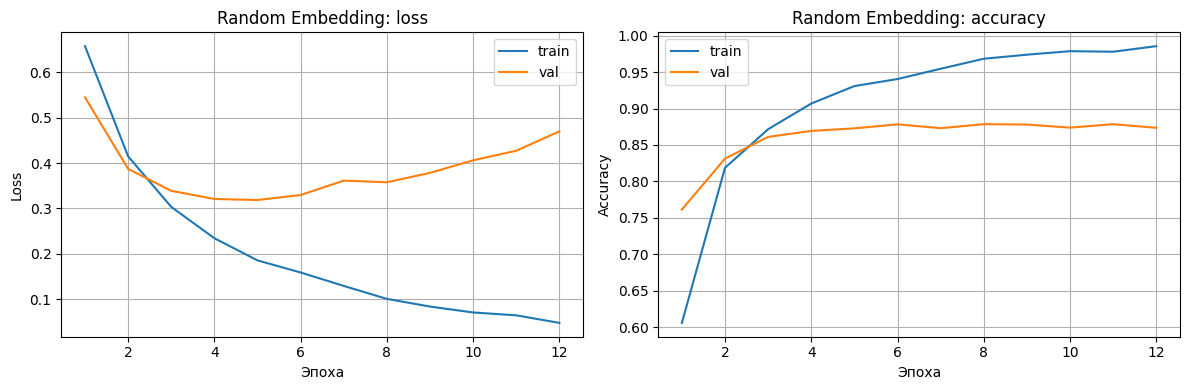

In [35]:
random_model = TextClassifier(len(word2idx))

history_random = train_model(
    random_model,
    train_loader,
    val_loader,
    test_loader,
    epochs=12,
    label="Random Embedding",
)

plot_training_history(history_random, "Random Embedding")


[GloVe frozen] epoch 1/12  train_loss=0.6465  train_acc=0.6321  val_loss=0.5947  val_acc=0.6670
[GloVe frozen] epoch 2/12  train_loss=0.5548  train_acc=0.7269  val_loss=0.5514  val_acc=0.7010
[GloVe frozen] epoch 3/12  train_loss=0.5242  train_acc=0.7490  val_loss=0.5097  val_acc=0.7548
[GloVe frozen] epoch 4/12  train_loss=0.5063  train_acc=0.7584  val_loss=0.5029  val_acc=0.7622
[GloVe frozen] epoch 5/12  train_loss=0.4966  train_acc=0.7666  val_loss=0.4924  val_acc=0.7600
[GloVe frozen] epoch 6/12  train_loss=0.4875  train_acc=0.7664  val_loss=0.4935  val_acc=0.7675
[GloVe frozen] epoch 7/12  train_loss=0.4817  train_acc=0.7712  val_loss=0.5328  val_acc=0.7328
[GloVe frozen] epoch 8/12  train_loss=0.4764  train_acc=0.7749  val_loss=0.4858  val_acc=0.7642
[GloVe frozen] epoch 9/12  train_loss=0.4741  train_acc=0.7770  val_loss=0.4884  val_acc=0.7668
[GloVe frozen] epoch 10/12  train_loss=0.4661  train_acc=0.7809  val_loss=0.5009  val_acc=0.7528
[GloVe frozen] epoch 11/12  train_loss=

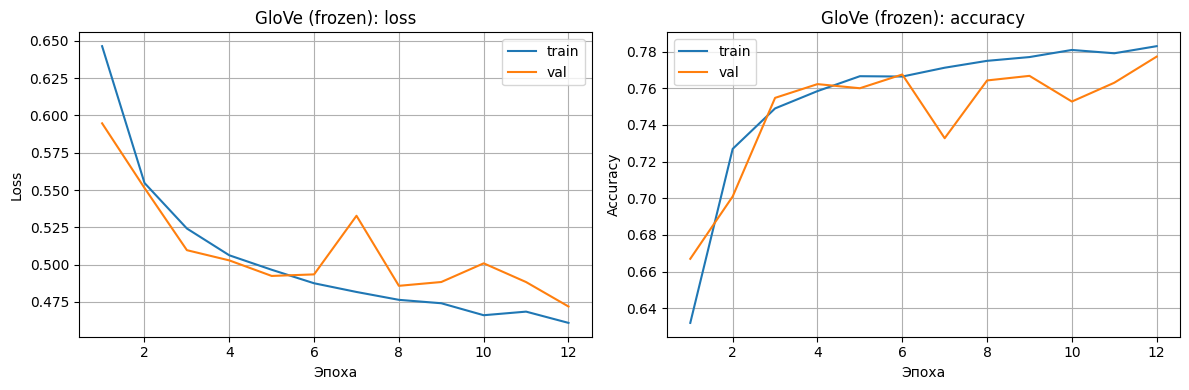

In [36]:
glove_model = TextClassifier(
    len(word2idx),
    embedding_matrix=embedding_matrix,
    freeze=True,
)

history_glove = train_model(
    glove_model,
    train_loader,
    val_loader,
    test_loader,
    epochs=12,
    label="GloVe frozen",
)

plot_training_history(history_glove, "GloVe (frozen)")


In [37]:
# метрики для итоговой таблицы (п. 14)
acc_tfidf = accuracy
acc_glove_avg = acc_emb
acc_nn_random = history_random["test_acc"]
acc_nn_glove = history_glove["test_acc"]

summary = pd.DataFrame({
    "Метод": [
        "Логистическая регрессия",
        "Логистическая регрессия",
        "Нейросеть",
        "Нейросеть",
    ],
    "Представление текста": [
        "TF-IDF",
        "Усреднённые GloVe",
        "Random Embedding",
        "GloVe (заморожен)",
    ],
    "Test Accuracy": [
        round(acc_tfidf, 4),
        round(acc_glove_avg, 4),
        round(acc_nn_random, 4),
        round(acc_nn_glove, 4),
    ],
})

print(summary.to_string(index=False))


                  Метод Представление текста  Test Accuracy
Логистическая регрессия               TF-IDF         0.8896
Логистическая регрессия    Усреднённые GloVe         0.7928
              Нейросеть     Random Embedding         0.8688
              Нейросеть    GloVe (заморожен)         0.7852


### Итоговая таблица и выводы (п. 14)

После запуска всех ячеек в таблице выше появятся четыре значения accuracy на **одном и том же test** (20% от IMDB train, stratified split).

**Ожидаемый порядок (типично):**
1. **TF-IDF + LR** — обычно лучший или близкий к лучшему на этой задаче: разреженные веса слов напрямую кодируют «плохой/хороший» лексикон отзывов.
2. **Random Embedding + NN** — хуже на старте, но может догнать за счёт обучения эмбеддингов.
3. **Усреднённые GloVe + LR** — теряется порядок слов; усреднение «размывает» сигнал.
4. **GloVe frozen + NN** — эмбеддинги общие, не под IMDB; заморозка не даёт адаптировать слой под отзывы.

**Почему TF-IDF часто выигрывает здесь:** бинарная тональность + мешок слов с сильными маркерами (`terrible`, `excellent`). Нейросеть с усреднением и 12 эпохами — более гибкая, но на IMDB без RNN/Transformer и без дообучения GloVe выигрыш не гарантирован.

**Разница Random vs GloVe (п. 13):** случайные векторы учатся с нуля только на 20k отзывов; GloVe уже несёт семантику из большого корпуса, но **заморозка** не позволяет подстроить векторы под «кино-лексику» — поэтому frozen GloVe не всегда лучше обучаемого Embedding.
